# 04 · Forecast: what private BEV share is plausible by 2028?

**Business question:** How fast is Sweden shifting to battery-electric cars among private buyers, where is it fastest or slowest and why, and what BEV share is plausible by 2028?

This notebook answers the last part, **what is plausible by 2028**, for the national private-buyer BEV share. It builds on the earlier notebooks:
- **01:** the private share is strongly seasonal (Sep and Dec spikes). 2026 is up 9 pp on 2025 (Jan–Aug), driven by BEV volume.
- **02:** counties move together, and regional splits are too noisy for a 2028 horizon. So this forecast is national.
- **03:** ending the climate bonus in Nov 2022 broke the trend. Growth went from +1 pp/month to flat. Monthly residuals are strongly autocorrelated. 03 recommended fitting on the post-bonus period only and presenting **scenarios rather than one line**.

**Rules from `CLAUDE.md`:**
- Shares stay within 0–1, and every forecast comes with intervals or scenarios.
- Annual shares are ratios of sums, never averages of monthly shares.
- Data runs through **Aug 2026**. The horizon is **Dec 2028** (28 months ahead).

## 1. Setup and data

**Choices made here**
- **Private buyers only**, built from the county fact table exactly as in 01 and 03. County 99 is included, because this is the national total.
- **Training window: Jan 2023 – Aug 2026** (44 months). 03 showed the bonus era (to Aug 2022) and the transition months (Sep–Dec 2022) belong to a different regime. Including them would carry the bonus-era growth rate of +1 pp/month into the forecast.
- **Logit transform**, $z_t = \log\big(s_t / (1 - s_t)\big)$. Every model forecasts $z$, and the forecasts are converted back with $s = 1/(1+e^{-z})$. Every forecast, and every simulated path, therefore stays strictly between 0 and 1. A constant trend in $z$ is also an S-curve in $s$: growth is fastest near 50% and slows towards 0% and 100%, which is how adoption curves usually behave.
- **Monthly data with month-of-year effects**, rather than a 12-month rolling share. The rolling share is smooth but lags by about six months (see 01), and the seasonal spikes are large enough to need modelling.

In [1]:
import sys
import logging
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.statespace.structural import UnobservedComponents

warnings.filterwarnings("ignore", message="IProgress not found")    # tqdm notice triggered by importing Prophet
logging.getLogger("prophet.plot").setLevel(logging.CRITICAL)           # "plotly not installed": only static plots are used
from prophet import Prophet
logging.getLogger("prophet").setLevel(logging.CRITICAL)
logging.getLogger("cmdstanpy").disabled = True                        # Stan sampler progress lines

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import viz
from viz import BLUE, ORANGE, AQUA, RED, INK, INK2, MUTED, GRID, AXIS, GREY_DARK, GREY_LIGHT, SURFACE, PCT
viz.apply_style()
PROC, FIGS = ROOT / "data" / "processed", ROOT / "docs" / "figures"
warnings.filterwarnings("ignore", module="statsmodels")   # optimizer chatter; convergence is checked explicitly below

fact = pd.read_csv(PROC / "fact_registrations_county_monthly.csv", parse_dates=["month"], dtype={"county_code": str})
w = fact[fact.owner_type == "private"].pivot_table(index="month", columns="fuel_type", values="registrations",
                                                   aggfunc="sum", fill_value=0)
pv = pd.DataFrame({"bev": w["BEV"], "total": w.sum(axis=1)}).asfreq("MS")
pv["share"] = pv.bev / pv.total
pv["logit"] = np.log(pv.share / (1 - pv.share))

T0, LAST, H_END = pd.Timestamp("2023-01-01"), pv.index.max(), pd.Timestamp("2028-12-01")
HORIZON = pd.date_range(LAST + pd.offsets.MonthBegin(1), H_END, freq="MS")
inv_logit = lambda z: 1 / (1 + np.exp(-z))
assert pv.share.between(0, 1, inclusive="neither").all() and pv.index.is_monotonic_increasing
print(f"Private series {pv.index.min():%b %Y}–{LAST:%b %Y}; training {T0:%b %Y}–{LAST:%b %Y} "
      f"({len(pv.loc[T0:])} months); forecast {HORIZON[0]:%b %Y}–{H_END:%b %Y} ({len(HORIZON)} months)")

Private series Jan 2021–Aug 2026; training Jan 2023–Aug 2026 (44 months); forecast Sep 2026–Dec 2028 (28 months)


## 2. The series to forecast

The training window is shaded. The rolling 12-month share (R12) is the smoothed reference from 01, drawn on top of the noisy monthly values.

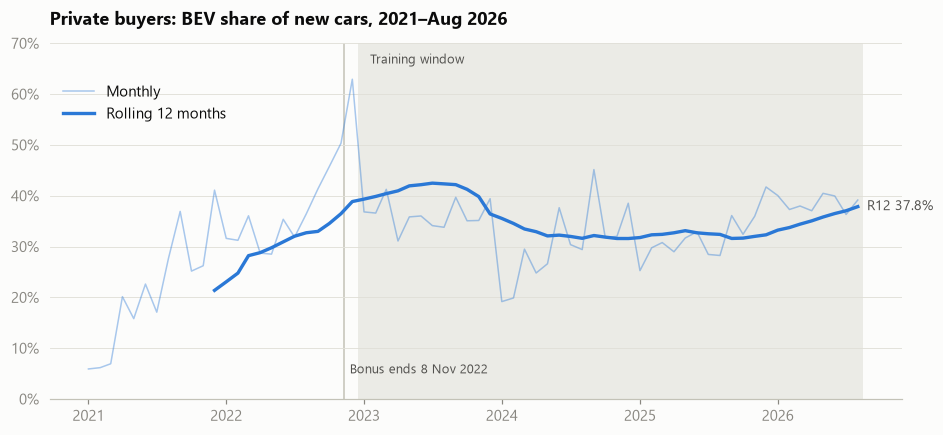

,R12 share,change vs year before (pp)
month,,
Aug 2022,32.7%,–
Aug 2023,42.3%,+9.6
Aug 2024,31.6%,-10.7
Aug 2025,32.4%,+0.8
Aug 2026,37.8%,+5.5


In [2]:
r12 = pv.bev.rolling(12).sum() / pv.total.rolling(12).sum()
fig, ax = plt.subplots()
ax.axvspan(T0 - pd.Timedelta(days=15), LAST + pd.Timedelta(days=15), color=GRID, alpha=0.6, lw=0)
ax.annotate("Training window", (T0, 0.66), xytext=(4, 0), textcoords="offset points", fontsize=8.5, color=INK2)
ax.plot(pv.index, pv.share, color=BLUE, lw=1, alpha=0.4, label="Monthly")
ax.plot(r12.index, r12, color=BLUE, lw=2.2, label="Rolling 12 months")
viz.mark_bonus(ax, y=0.1)
viz.label_end(ax, r12, f"R12 {r12.iloc[-1]:.1%}")
ax.yaxis.set_major_formatter(PCT)
ax.set_ylim(0, 0.7)
ax.set_title("Private buyers: BEV share of new cars, 2021–Aug 2026")
ax.legend(loc="upper left", bbox_to_anchor=(0, 0.92))
viz.save(fig, "04_series", FIGS)
plt.show()

aug = pd.DataFrame({"R12 share": r12[r12.index.month == 8], "change vs year before (pp)": r12[r12.index.month == 8].diff() * 100})
aug.index = aug.index.strftime("Aug %Y")
aug.dropna(subset=["R12 share"]).style.format({"R12 share": "{:.1%}", "change vs year before (pp)": "{:+.1f}"}, na_rep="–")

**What the forecast has to deal with**
- **Two regimes inside the training window.** R12 peaked at 42.3% in Aug 2023, mechanically, because the Dec 2022 rush was still in the window. It then fell to 31.6% (Aug 2024) and stayed there (32.4% in Aug 2025). From late 2025 it **rose by 5.5 pp in a year**, to 37.8%. A model has to decide whether that rise is a new trend or a level shift that will stop.
- **Only 44 training months**, and the turn is in the last 12 of them. Any estimate of a post-bonus *slope* rests on very few observations after the turn. That's the main reason the scenarios below differ so much.

## 3. Candidate models

All four models forecast the logit share and include **month-of-year effects** (11 dummies, or Fourier terms in Prophet). They differ in what they assume about the **trend**, and that assumption is the real uncertainty here:

| Model | Trend assumption | Scenario it represents |
|---|---|---|
| **Plateau**: local level (`UnobservedComponents`, `llevel`) | The level wanders as a random walk with no drift. The best guess is "stays where it is now", with uncertainty growing over time. | The 2026 step up holds, but no further growth |
| **Reversion**: linear trend + AR(1) errors (`SARIMAX`) | One straight trend through all of 2023–26. Deviations die out at the AR(1) rate. | The 2026 rise is a temporary swing above the post-bonus trend and fades |
| **Momentum**: local linear trend (`UnobservedComponents`, `lltrend`) | Both level and slope are stochastic. The current slope continues, which on the logit scale bends into an S-curve. | The 2026 restart continues |
| **Prophet**: logistic growth, cap = 1 | A piecewise-linear trend with automatic changepoints, bounded at 0 and 1. | Cross-check: an off-the-shelf bounded growth model |

**Why state-space models.** 03 found strong residual autocorrelation (Durbin–Watson ≈ 0.8). The state-space models handle it inside the model, through the random-walk level or the AR(1) term. Their **simulated paths** then carry that persistence into the forecast intervals. Intervals that ignore autocorrelation would be too narrow.

**Prophet** is in the project's requirements and is the standard choice for "logistic growth with a cap". It's included so its intervals can be compared with the others in the backtest (section 4).

In [3]:
def month_dummies(idx):
    return pd.get_dummies(idx.month, prefix="m", drop_first=True, dtype=float).set_index(idx)


def fit_models(train):
    # Fit the three state-space models on a training slice of pv; returns {name: results}
    y, X = train.logit, month_dummies(train.index)
    t = pd.Series(np.arange(len(y)) / 12, index=y.index, name="t")      # years since Jan 2023: keeps the optimizer well scaled
    models = {
        "Plateau": UnobservedComponents(y, level="llevel", exog=X),
        "Reversion": SARIMAX(y, exog=X.join(t), order=(1, 0, 0), trend="c"),
        "Momentum": UnobservedComponents(y, level="lltrend", exog=X),
    }
    fits = {k: m.fit(disp=False, maxiter=2000) for k, m in models.items()}
    for k, f in fits.items():
        assert f.mle_retvals["converged"], f"{k} did not converge"
    return fits


def simulate(fits, n_train, idx, reps=2000, seed=4):
    # Simulated share paths (len(idx) x reps) for each state-space model, starting after the training data
    X = month_dummies(idx)
    t = pd.Series(np.arange(n_train, n_train + len(idx)) / 12, index=idx, name="t")
    out = {}
    for i, (k, f) in enumerate(fits.items()):
        ex = X.join(t) if k == "Reversion" else X
        z = f.simulate(len(idx), repetitions=reps, anchor="end", exog=ex, rng=np.random.default_rng(seed + i))
        out[k] = inv_logit(np.asarray(z).reshape(len(idx), reps))
    return out


def prophet_paths(train, idx, reps=2000, seed=4):
    d = pd.DataFrame({"ds": train.index, "y": train.share.values, "cap": 1.0, "floor": 0.0})
    m = Prophet(growth="logistic", yearly_seasonality=4, weekly_seasonality=False, daily_seasonality=False,
                uncertainty_samples=reps).fit(d)
    np.random.seed(seed)
    s = m.predictive_samples(pd.DataFrame({"ds": idx, "cap": 1.0, "floor": 0.0}))["yhat"]
    return np.clip(s, 1e-6, 1 - 1e-6)


fits = fit_models(pv.loc[T0:])
summary = pd.DataFrame({
    "Plateau": {"level variance": fits["Plateau"].params["sigma2.level"],
                "irregular variance": fits["Plateau"].params["sigma2.irregular"]},
    "Reversion": {"trend (logit / year)": fits["Reversion"].params["t"], "AR(1)": fits["Reversion"].params["ar.L1"],
                  "innovation variance": fits["Reversion"].params["sigma2"]},
    "Momentum": {"level variance": fits["Momentum"].params["sigma2.level"],
                 "slope variance": fits["Momentum"].params["sigma2.trend"],
                 "irregular variance": fits["Momentum"].params["sigma2.irregular"],
                 "slope at Aug 2026 (logit / year)": fits["Momentum"].smoothed_state[1, -1] * 12},
}).T
summary.style.format("{:.4f}", na_rep="").set_caption("Key parameters, fitted on Jan 2023 – Aug 2026")

,level variance,irregular variance,trend (logit / year),AR(1),innovation variance,slope variance,slope at Aug 2026 (logit / year)
Plateau,0.0115,0.0086,,,,,
Reversion,,,0.0252,0.7222,0.0248,,
Momentum,0.0110,0.0088,,,,0.0001,0.1590


**Reading the parameters**
- **Plateau:** the level variance is about as large as the irregular (month-to-month) variance. The model sees the level as genuinely moving, not as noise around a fixed mean. Its intervals therefore widen quickly with the horizon.
- **Reversion:** the fitted trend is only 0.025 logit per year, about +0.6 pp per year near a 35–40% share. That's essentially the flat post-bonus trend 03 found. An AR(1) coefficient of 0.72 means a deviation from that line halves in about two months. This model reads the 2026 rise as a swing that will fade.
- **Momentum:** the slope variance is close to zero, so the slope changes only slowly. Its smoothed value at Aug 2026 is **0.16 logit per year (≈ +3.8 pp per year at 40%)**, six times the Reversion trend, because the level ended the window high and rising. This model extrapolates that slope, flattening as it approaches 100%.

## 4. Backtest: how well would these models have forecast the last year?

**Holdout design.** Each model is refitted on data up to a forecast origin and then forecasts the next 12 months, which are compared with what actually happened. There are two origins:
- **Aug 2024** (training Jan 2023 – Aug 2024, test Sep 2024 – Aug 2025): a quiet year with no regime change.
- **Aug 2025** (training Jan 2023 – Aug 2025, test Sep 2025 – Aug 2026): the year of the restart.

**Metrics**
- **MAE** and **bias** of the monthly median forecast, in pp.
- **80% interval coverage**: the share of test months that fall inside the 80% interval. A well-calibrated model is near 80%.
- The **R12 share at the end of the test year**, which is the annual figure the business question cares about.

A **seasonal naive** forecast (same month last year) is the benchmark. A model that can't beat it adds nothing.

**Caveat:** two origins, with 12 months each and short training windows (20 and 32 months). This shows how the models behave, but it's too small for a formal model ranking.

In [4]:
def backtest(origin):
    train, test = pv.loc[T0:origin], pv.loc[origin + pd.offsets.MonthBegin(1):origin + pd.DateOffset(months=12)]
    paths = simulate(fit_models(train), len(train), test.index)
    paths["Prophet"] = prophet_paths(train, test.index)
    paths["Seasonal naive"] = pv.share.shift(12).loc[test.index].to_numpy()[:, None]
    actual_r12 = test.bev.sum() / test.total.sum()
    rows, medians = [], {}
    for k, p in paths.items():
        med = np.median(p, axis=1)
        lo, hi = np.percentile(p, [10, 90], axis=1)
        r12_paths = (p * test.total.to_numpy()[:, None]).sum(axis=0) / test.total.sum()
        rows.append({"origin": f"{origin:%b %Y}", "model": k,
                     "MAE (pp)": np.abs(med - test.share).mean() * 100,
                     "bias (pp)": (med - test.share).mean() * 100,
                     "80% coverage": np.nan if p.shape[1] == 1 else ((test.share >= lo) & (test.share <= hi)).mean(),
                     "R12 forecast": np.median(r12_paths), "R12 actual": actual_r12})
        medians[k] = pd.Series(med, index=test.index)
    return pd.DataFrame(rows), medians


bt = {}
for origin in [pd.Timestamp("2024-08-01"), pd.Timestamp("2025-08-01")]:
    bt[origin] = backtest(origin)
res = pd.concat([r for r, _ in bt.values()])
res.style.format({"MAE (pp)": "{:.1f}", "bias (pp)": "{:+.1f}", "80% coverage": "{:.0%}", "R12 forecast": "{:.1%}",
                  "R12 actual": "{:.1%}"}, na_rep="–").hide(axis="index") \
   .set_caption("12-month-ahead backtest from two forecast origins")

origin,model,MAE (pp),bias (pp),80% coverage,R12 forecast,R12 actual
Aug 2024,Plateau,3.4,-1.9,83%,30.7%,32.4%
Aug 2024,Reversion,9.1,-9.1,17%,23.5%,32.4%
Aug 2024,Momentum,6.8,-6.7,75%,26.1%,32.4%
Aug 2024,Prophet,9.2,-9.2,8%,23.4%,32.4%
Aug 2024,Seasonal naive,3.9,-1.4,–,31.3%,32.4%
Aug 2025,Plateau,8.6,-8.0,50%,30.4%,37.8%
Aug 2025,Reversion,11.1,-10.7,17%,27.6%,37.8%
Aug 2025,Momentum,13.1,-12.7,33%,25.7%,37.8%
Aug 2025,Prophet,10.3,-10.2,17%,28.1%,37.8%
Aug 2025,Seasonal naive,7.4,-5.9,–,32.3%,37.8%


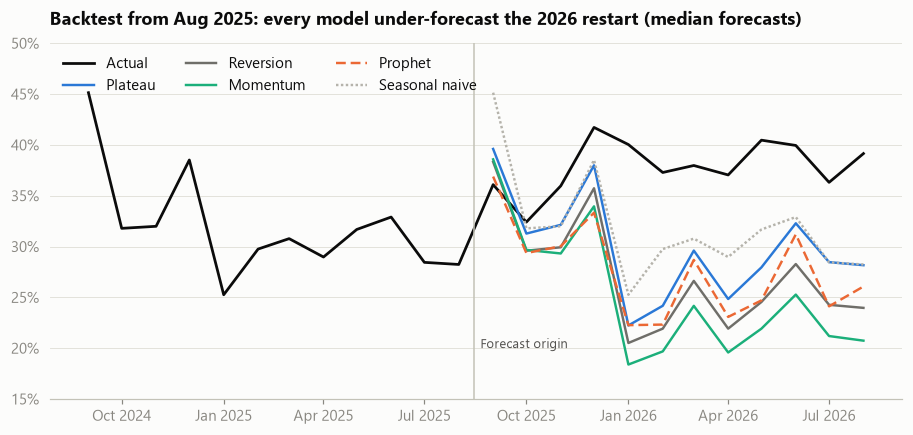

In [5]:
_, med = bt[pd.Timestamp("2025-08-01")]
fig, ax = plt.subplots()
hist = pv.loc["2024-09":]
ax.plot(hist.index, hist.share, color=INK, lw=1.8, label="Actual")
styles = {"Plateau": (BLUE, "-"), "Reversion": (GREY_DARK, "-"), "Momentum": (AQUA, "-"),
          "Prophet": (ORANGE, (0, (4, 2))), "Seasonal naive": (GREY_LIGHT, (0, (1, 1)))}
for k, (c, ls) in styles.items():
    ax.plot(med[k].index, med[k], color=c, lw=1.6, ls=ls, label=k)
ax.axvline(pd.Timestamp("2025-08-15"), color=AXIS, lw=1)
ax.annotate("Forecast origin", (pd.Timestamp("2025-08-15"), 0.2), xytext=(4, 0), textcoords="offset points",
            fontsize=8.5, color=INK2)
ax.yaxis.set_major_formatter(PCT)
ax.xaxis.set_major_formatter(mpl.dates.DateFormatter("%b %Y"))
ax.set_ylim(0.15, 0.5)
ax.set_title("Backtest from Aug 2025: every model under-forecast the 2026 restart (median forecasts)")
ax.legend(loc="upper left", ncol=3)
viz.save(fig, "04_backtest", FIGS)
plt.show()

**What the backtest shows** (numbers from the table above)
- **From Aug 2024, a quiet year, only the level models worked.**
  - **Plateau** was best: MAE 3.4 pp, 83% interval coverage, and an R12 forecast of 30.7% against an actual 32.4%. Seasonal naive was close behind.
  - **Reversion, Momentum and Prophet** were 7–9 pp too low. Their training window (Jan 2023 – Aug 2024) was dominated by the post-rush decline, so they extrapolated a falling trend that stopped.
- **From Aug 2025, no model saw the restart coming.**
  - Every forecast is biased low by 6–13 pp a month, and every R12 forecast misses the actual 37.8% by 5–12 pp.
  - Seasonal naive (MAE 7.4) and Plateau (8.6, 50% coverage) did least badly.
  - The slope models were again worst, this time because their trend was flat just before the turn.
- **Lesson: in this series, slopes estimated from 1–3 years of data have pointed the wrong way at both origins.** A model that assumes "the level persists, with growing uncertainty" was the most reliable. **Plateau is therefore the central case** below.
- **Intervals were too narrow at the turning point.** **Prophet** was the worst calibrated at both origins (8% and 17% coverage against a nominal 80%), so it's dropped from the scenarios. The statistical uncertainty within one regime is much smaller than the uncertainty about *which regime comes next*.
- Reversion and Momentum are kept, but as **downside and upside scenarios**: one each for "the 2026 rise fades" and "the 2026 rise continues". They are not predictions in their own right.